# In-Domain Handcrafted Linguistic Feature Stability Analysis (ADReSS)

Within each grouped stratified fold, highly correlated predictors were first removed using Pearson pruning (|r| > .70). L1-regularized logistic regression was then applied for sparse feature selection and in-domain diagnosis classification. Only non-zero coefficients were treated as selected features for stability analysis.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [2]:
DATA_PATH  = "/Users/gloria/Documents/uniproject/thesis/outputs/adress_extractedfeatures.csv"
OUTPUT_DIR = "/Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output"
VIZ_DIR    = "/Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations"

df = pd.read_csv(DATA_PATH)

EXCLUDE_COLS = ["ID", "age", "gender", "mmse", "original_utterances", "aggregated_utterances"]
TARGET = "diagnosis"

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET]]

X = df[feature_cols].copy()
X = X.select_dtypes(include=[np.number]).copy()
feature_cols = list(X.columns)
y = df[TARGET].values

# Determine grouping strategy
n_unique_ids = df["ID"].nunique()
n_rows = len(df)
print(f"Unique IDs: {n_unique_ids}, Total rows: {n_rows}")

if n_unique_ids == n_rows:
    print("Each ID is unique — using StratifiedKFold (no groups needed)")
    USE_GROUPS = False
    groups = None
else:
    print("Repeated IDs detected — using StratifiedGroupKFold with groups=ID")
    USE_GROUPS = True
    groups = df["ID"].values

print(f"Total candidate predictors before pruning: {len(feature_cols)}")
print(f"Dataset shape: {df.shape}")
print(f"Unique participants: {n_unique_ids}")

Unique IDs: 156, Total rows: 156
Each ID is unique — using StratifiedKFold (no groups needed)
Total candidate predictors before pruning: 46
Dataset shape: (156, 52)
Unique participants: 156


## Constant Feature Removal

Constant features are removed because Pearson correlation is undefined for variables with zero variance. This is a data-cleaning step, not an additional feature-selection method.

In [3]:
# Drop constant numeric features (std = 0) before correlation and pruning
os.makedirs(OUTPUT_DIR, exist_ok=True)

constant_features = list(X.columns[X.std() == 0])
X = X.loc[:, X.std() > 0]
feature_cols = list(X.columns)

print(f"Constant features removed: {len(constant_features)}")
if constant_features:
    for f in constant_features:
        print(f"  - {f}")
else:
    print("  (none)")
print(f"Feature count after constant removal: {len(feature_cols)}")

pd.DataFrame({"constant_feature": constant_features}).to_csv(
    os.path.join(OUTPUT_DIR, "adress_constant_features_removed.csv"), index=False
)
print(f"Saved: {OUTPUT_DIR}/adress_constant_features_removed.csv")

Constant features removed: 0
  (none)
Feature count after constant removal: 46
Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_constant_features_removed.csv


In [4]:
def pearson_prune(X_train, threshold=0.70):
    """Upper-triangle deterministic Pearson correlation pruning.
    Returns retained feature list and list of (kept, dropped, correlation) tuples."""
    corr = X_train.corr(method="pearson").abs()
    cols = list(X_train.columns)
    to_drop = set()
    dropped_pairs = []
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if cols[j] in to_drop:
                continue
            r = corr.loc[cols[i], cols[j]]
            if r > threshold:
                to_drop.add(cols[j])
                dropped_pairs.append((cols[i], cols[j], round(float(r), 4)))
    retained = [c for c in cols if c not in to_drop]
    return retained, dropped_pairs

In [5]:
# STEP 1: Global Pearson pruning (before CV loop)
retained, dropped_pairs_global = pearson_prune(X, threshold=0.70)
X_pruned = X[retained]
print(f"Pearson pruning: {len(feature_cols)} → {len(retained)} features retained")
for kept, dropped, r in dropped_pairs_global:
    print(f"  dropped '{dropped}' (r={r} with '{kept}')")

# STEP 2: CV loop
if USE_GROUPS:
    splitter = StratifiedGroupKFold(n_splits=5)
    split_iter = splitter.split(X_pruned, y, groups)
else:
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    split_iter = splitter.split(X_pruned, y)

all_fold_coefficients = []
all_fold_performance = []

for fold_idx, (train_idx, test_idx) in enumerate(split_iter, start=1):
    X_train = X_pruned.iloc[train_idx]
    y_train = y[train_idx]
    X_test  = X_pruned.iloc[test_idx]
    y_test  = y[test_idx]

    # Scale — fit on train only, transform both
    # fillna(0): zero-variance features in a fold produce NaN after scaling
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=retained).fillna(0)
    X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=retained).fillna(0)

    # L1 logistic regression
    lr = LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced",
                            max_iter=5000, C=1.0)
    lr.fit(X_train_s, y_train)

    # Store only non-zero coefficients
    coef_series = pd.Series(lr.coef_[0], index=retained)
    nonzero_coefs = coef_series[coef_series != 0]
    print(f"Fold {fold_idx}: {len(nonzero_coefs)} non-zero L1-selected features")

    for feat, coef in nonzero_coefs.items():
        all_fold_coefficients.append({
            "fold": fold_idx,
            "feature": feat,
            "coefficient": coef,
            "abs_coefficient": abs(coef),
            "direction": "positive" if coef > 0 else "negative",
        })

    # Evaluation on held-out test fold
    y_pred = lr.predict(X_test_s)
    y_prob = lr.predict_proba(X_test_s)[:, 1]
    all_fold_performance.append({
        "fold": fold_idx,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "auc":       roc_auc_score(y_test, y_prob),
    })

fold_coef_df = pd.DataFrame(all_fold_coefficients)
dropped_pairs_df = pd.DataFrame([
    {"kept_feature": k, "dropped_feature": d, "correlation": r}
    for k, d, r in dropped_pairs_global
])
fold_perf_df = pd.DataFrame(all_fold_performance)

avg_perf = fold_perf_df.drop(columns="fold").mean()
std_perf = fold_perf_df.drop(columns="fold").std()

print(f"\nTotal foldwise coefficient rows (non-zero only): {len(fold_coef_df)}")
print(f"Total dropped pairs recorded: {len(dropped_pairs_df)}")
print(f"\nIn-domain performance (mean ± std across 5 folds):")
for m in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f"  {m:10s}: {avg_perf[m]:.3f} ± {std_perf[m]:.3f}")

fold_coef_df.head()

Pearson pruning: 46 → 34 features retained
  dropped 'ttr' (r=0.983 with 'n_lemmas')
  dropped 'n_low_aoa' (r=0.9611 with 'n_lemmas')
  dropped 'tree_depth' (r=0.8089 with 'tokens_per_sentence')
  dropped 'avg_Haptic_sensorimotor' (r=0.8734 with 'avg_concreteness')
  dropped 'avg_Visual_sensorimotor' (r=0.867 with 'avg_concreteness')
  dropped 'n_noun' (r=0.7617 with 'avg_concreteness')
  dropped 'avg_Torso_sensorimotor' (r=0.765 with 'avg_Foot_leg_sensorimotor')
  dropped 'n_VERB_Tense_Pres' (r=0.7368 with 'n_verb')
  dropped 'pronoun_noun_ratio' (r=0.8825 with 'n_pron')
  dropped 'verb_noun_ratio' (r=0.7355 with 'n_pron')
  dropped 'filler_to_noun_ratio' (r=0.8941 with 'n_intj')
  dropped 'particle_verb_ratio' (r=0.7399 with 'n_part')
Fold 1: 26 non-zero L1-selected features
Fold 2: 29 non-zero L1-selected features
Fold 3: 25 non-zero L1-selected features
Fold 4: 30 non-zero L1-selected features
Fold 5: 25 non-zero L1-selected features

Total foldwise coefficient rows (non-zero only)

/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to 

,fold,feature,coefficient,abs_coefficient,direction
0,1,avg_word_length,-0.608919,0.608919,negative
1,1,n_polysyllables,-0.261088,0.261088,negative
2,1,n_monosyllables,0.391762,0.391762,positive
3,1,n_lemmas,-0.405946,0.405946,negative
4,1,tokens_per_sentence,-0.411555,0.411555,negative


## Pearson Correlation Analysis (Pre-Pruning)

Pearson correlation measures the strength and direction of the **linear relationship** between pairs of features. Values range from −1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear association.

Highly correlated features (|r| > 0.70) are likely to carry **redundant information**: including both in a model can inflate variance and reduce interpretability without improving predictive power. The heatmap below shows the signed correlation structure of the full feature set before any pruning, using a diverging colormap centred at 0 (red = positive correlation, blue = negative correlation).

The table of highly correlated pairs (|r| > 0.70) identifies candidates for removal; the subsequent Pearson pruning step uses absolute correlations to deterministically drop one feature from each such pair.

Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_pearson_correlation_matrix.csv


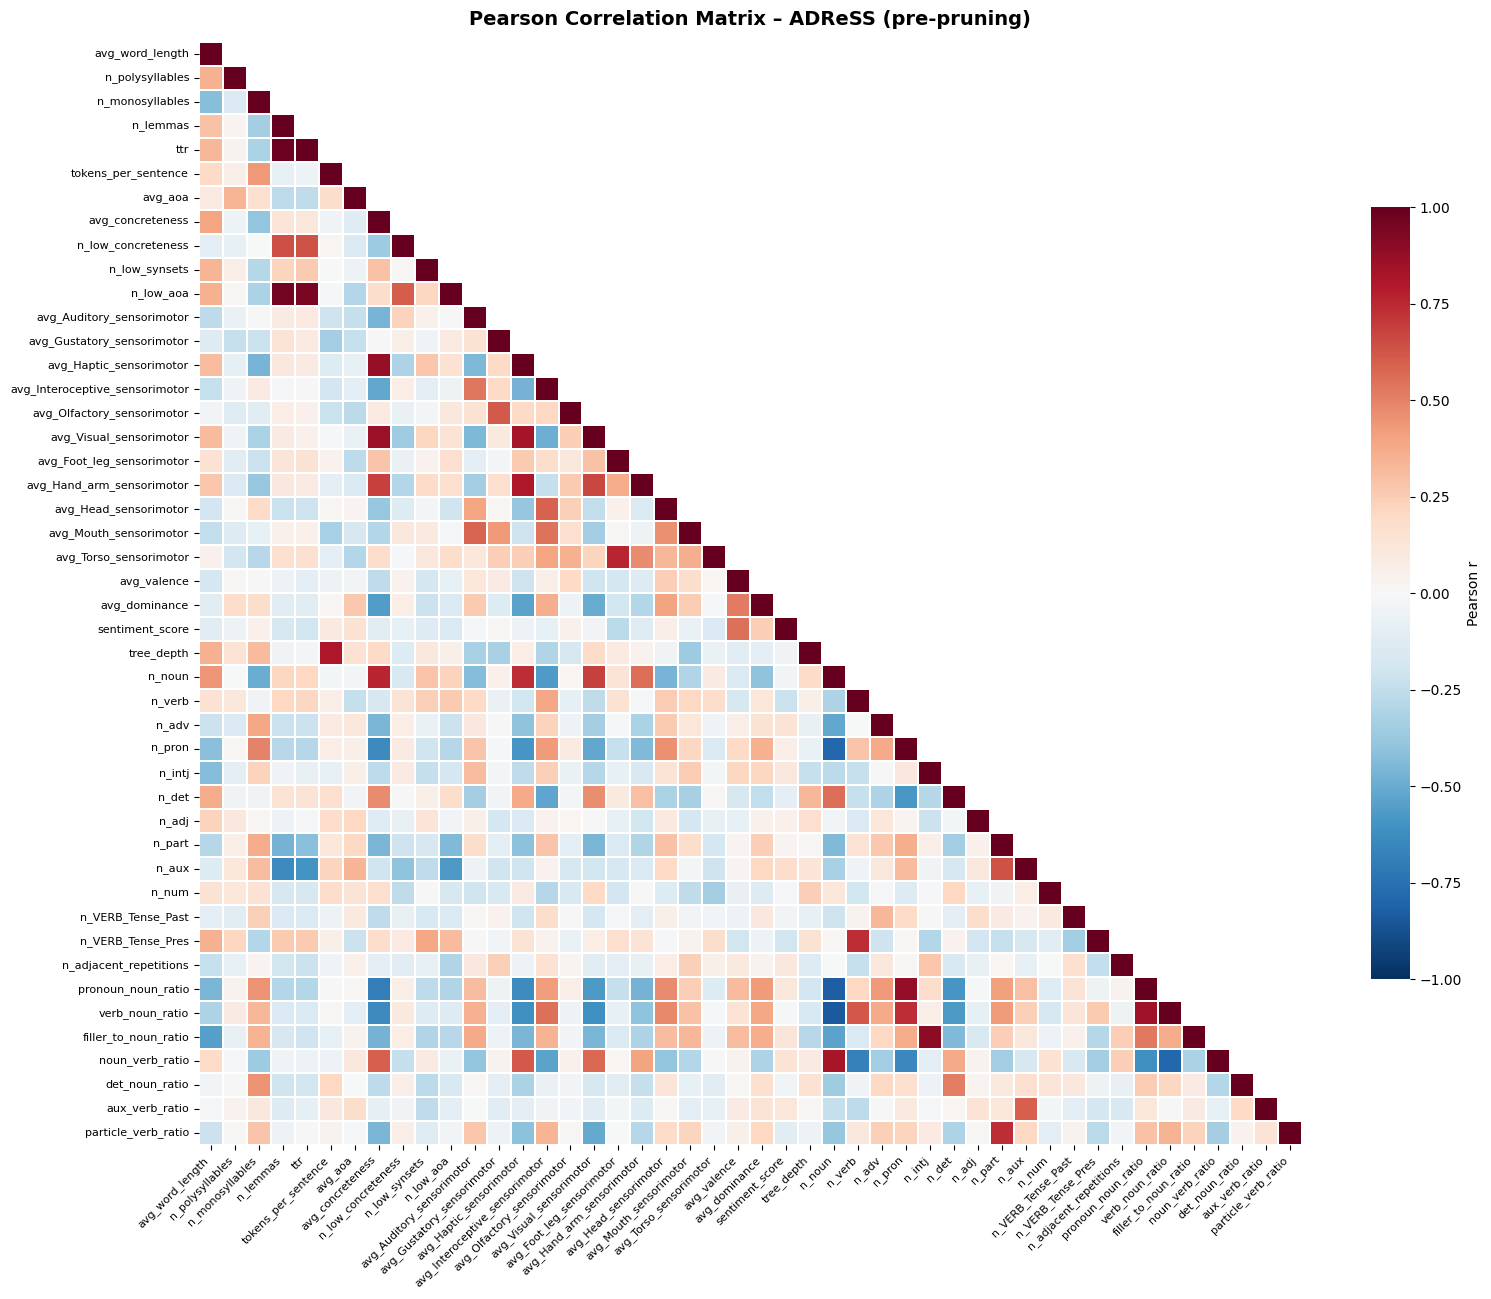

Saved: /Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations/adress_pearson_correlation_heatmap.png
Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_highly_correlated_pairs.csv
Highly correlated pairs (|r| > 0.70): 22


,feature_1,feature_2,pearson_correlation,abs_correlation
0,n_lemmas,ttr,0.9830,0.9830
1,n_lemmas,n_low_aoa,0.9611,0.9611
2,ttr,n_low_aoa,0.9502,0.9502
3,n_intj,filler_to_noun_ratio,0.8941,0.8941
4,n_pron,pronoun_noun_ratio,0.8825,0.8825
5,avg_concreteness,avg_Haptic_sensorimotor,0.8734,0.8734
6,avg_concreteness,avg_Visual_sensorimotor,0.8670,0.8670
7,pronoun_noun_ratio,verb_noun_ratio,0.8498,0.8498
8,n_noun,verb_noun_ratio,-0.8373,0.8373
9,avg_Haptic_sensorimotor,avg_Visual_sensorimotor,0.8295,0.8295


In [6]:
# ── Pearson Correlation Heatmap (pre-pruning, signed) ─────────────────────────
# Signed Pearson correlation matrix on the cleaned numeric feature matrix (after constant removal)
corr_signed = X.corr(method="pearson")

# Save signed correlation matrix as CSV
corr_signed.to_csv(os.path.join(OUTPUT_DIR, "adress_pearson_correlation_matrix.csv"))
print(f"Saved: {OUTPUT_DIR}/adress_pearson_correlation_matrix.csv")

# Heatmap: lower-triangle mask with k=1 so diagonal is visible
mask = np.triu(np.ones_like(corr_signed, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_signed,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    square=True,
    cbar_kws={"label": "Pearson r", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix – ADReSS (pre-pruning)", fontsize=14, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "adress_pearson_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {VIZ_DIR}/adress_pearson_correlation_heatmap.png")

# Highly correlated feature pairs using absolute correlation (threshold > 0.70)
cols = list(corr_signed.columns)
high_corr_rows = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_signed.loc[cols[i], cols[j]]
        r_abs = abs(r)
        if r_abs > 0.70:
            high_corr_rows.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "pearson_correlation": round(float(r), 4),
                "abs_correlation": round(float(r_abs), 4),
            })
high_corr_df = (
    pd.DataFrame(high_corr_rows)
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)
high_corr_df.to_csv(os.path.join(OUTPUT_DIR, "adress_highly_correlated_pairs.csv"), index=False)
print(f"Saved: {OUTPUT_DIR}/adress_highly_correlated_pairs.csv")
print(f"Highly correlated pairs (|r| > 0.70): {len(high_corr_df)}")
high_corr_df

In [7]:
# Aggregated feature stability summary
summary_rows = []

for feat in fold_coef_df["feature"].unique():
    feat_df = fold_coef_df[fold_coef_df["feature"] == feat]
    selected_folds = len(feat_df)
    avg_coef = feat_df["coefficient"].mean()
    avg_abs_coef = feat_df["abs_coefficient"].mean()
    directions = list(feat_df["direction"])
    stable_direction = len(set(directions)) == 1
    majority_direction = feat_df["direction"].mode()[0]
    summary_rows.append({
        "feature": feat,
        "selected_folds": selected_folds,
        "avg_coefficient": avg_coef,
        "avg_abs_coefficient": avg_abs_coef,
        "directions": directions,
        "stable_direction": stable_direction,
        "majority_direction": majority_direction,
        "stable": stable_direction and selected_folds >= 3,
    })

stability_summary = pd.DataFrame(summary_rows)
print(f"Features in stability summary: {len(stability_summary)}")
print(f"Stable-direction features: {stability_summary['stable_direction'].sum()}")
print(f"Stable features (direction + ≥3 folds): {stability_summary['stable'].sum()}")
stability_summary.head(10)

Features in stability summary: 34
Stable-direction features: 29
Stable features (direction + ≥3 folds): 25


,feature,selected_folds,avg_coefficient,avg_abs_coefficient,directions,stable_direction,majority_direction,stable
0,avg_word_length,5,-0.743980,0.743980,"[negative, negative, negative, negative, negat...",True,negative,True
1,n_polysyllables,4,-0.236467,0.236467,"[negative, negative, negative, negative]",True,negative,True
2,n_monosyllables,5,0.450322,0.450322,"[positive, positive, positive, positive, posit...",True,positive,True
3,n_lemmas,4,-0.564596,0.564596,"[negative, negative, negative, negative]",True,negative,True
4,tokens_per_sentence,5,-0.390212,0.390212,"[negative, negative, negative, negative, negat...",True,negative,True
5,avg_concreteness,3,0.139643,0.271353,"[positive, positive, negative]",False,positive,False
6,n_low_concreteness,5,0.551010,0.551010,"[positive, positive, positive, positive, posit...",True,positive,True
7,n_low_synsets,5,0.477022,0.477022,"[positive, positive, positive, positive, posit...",True,positive,True
8,avg_Auditory_sensorimotor,5,0.222356,0.222356,"[positive, positive, positive, positive, posit...",True,positive,True
9,avg_Olfactory_sensorimotor,5,0.467233,0.467233,"[positive, positive, positive, positive, posit...",True,positive,True


In [8]:
# Final ranking: stable features only (consistent direction + selected in ≥3 folds)
stable_ranked_features = (
    stability_summary[stability_summary["stable"]]
    .sort_values(["selected_folds", "avg_abs_coefficient"], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"Stable ranked features: {len(stable_ranked_features)}")
print("\nTop 15 final stable ranked features:")
print(stable_ranked_features[["feature", "selected_folds", "avg_abs_coefficient", "majority_direction"]].head(15).to_string(index=False))

Stable ranked features: 25

Top 15 final stable ranked features:
                   feature  selected_folds  avg_abs_coefficient majority_direction
    n_adjacent_repetitions               5             0.932563           positive
           sentiment_score               5             0.878232           negative
           avg_word_length               5             0.743980           negative
    avg_Mouth_sensorimotor               5             0.554280           negative
        n_low_concreteness               5             0.551010           positive
                     n_adv               5             0.549530           positive
                     n_aux               5             0.540661           negative
             n_low_synsets               5             0.477022           positive
avg_Olfactory_sensorimotor               5             0.467233           positive
           n_monosyllables               5             0.450322           positive
            aux_verb_r

In [9]:
# Save CSV outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

fold_coef_df.to_csv(os.path.join(OUTPUT_DIR, "adress_fold_coefficients.csv"), index=False)
stability_summary.to_csv(os.path.join(OUTPUT_DIR, "adress_feature_stability_summary.csv"), index=False)
stable_ranked_features.to_csv(os.path.join(OUTPUT_DIR, "adress_stable_ranked_features.csv"), index=False)
dropped_pairs_df.to_csv(os.path.join(OUTPUT_DIR, "adress_correlation_dropped_pairs.csv"), index=False)
fold_perf_df.to_csv(os.path.join(OUTPUT_DIR, "adress_fold_performance_metrics.csv"), index=False)

avg_perf_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "auc"],
    "mean":   [avg_perf[m] for m in ["accuracy", "precision", "recall", "f1", "auc"]],
    "std":    [std_perf[m] for m in ["accuracy", "precision", "recall", "f1", "auc"]],
})
avg_perf_df.to_csv(os.path.join(OUTPUT_DIR, "adress_average_performance_metrics.csv"), index=False)

print("Saved:")
for f in [
    "adress_fold_coefficients.csv",
    "adress_feature_stability_summary.csv",
    "adress_stable_ranked_features.csv",
    "adress_correlation_dropped_pairs.csv",
    "adress_fold_performance_metrics.csv",
    "adress_average_performance_metrics.csv",
]:
    print(f"  {OUTPUT_DIR}/{f}")

Saved:
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_fold_coefficients.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_feature_stability_summary.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_stable_ranked_features.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_correlation_dropped_pairs.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_fold_performance_metrics.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/adress_average_performance_metrics.csv


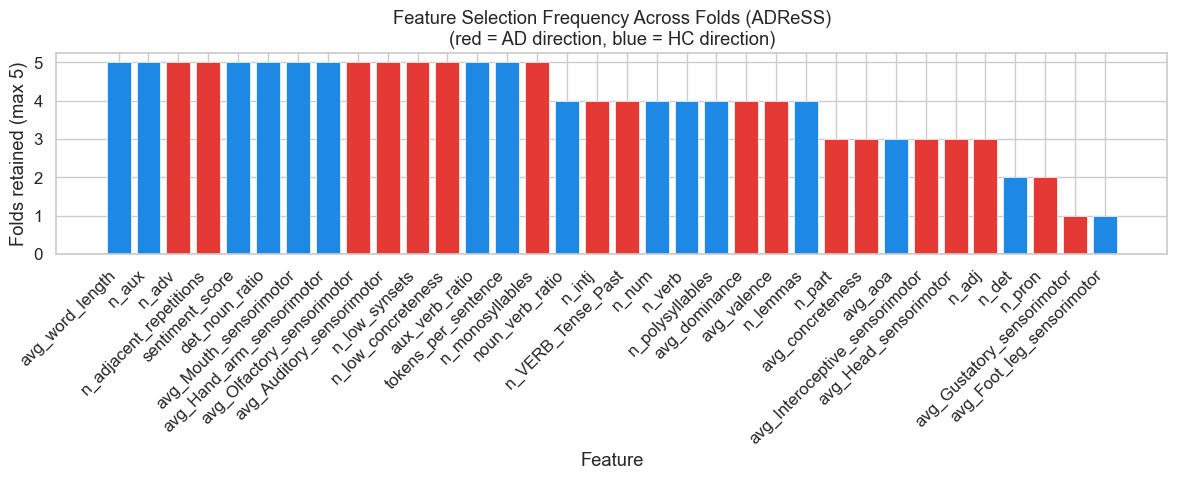

Saved: adress_feature_selection_frequency.png


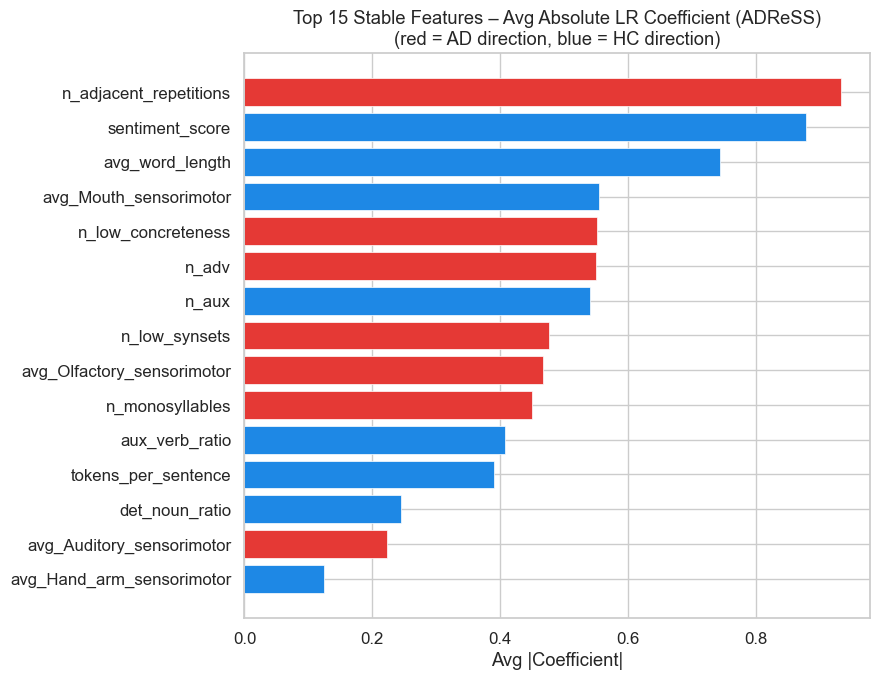

Saved: adress_stable_features_coefficients.png


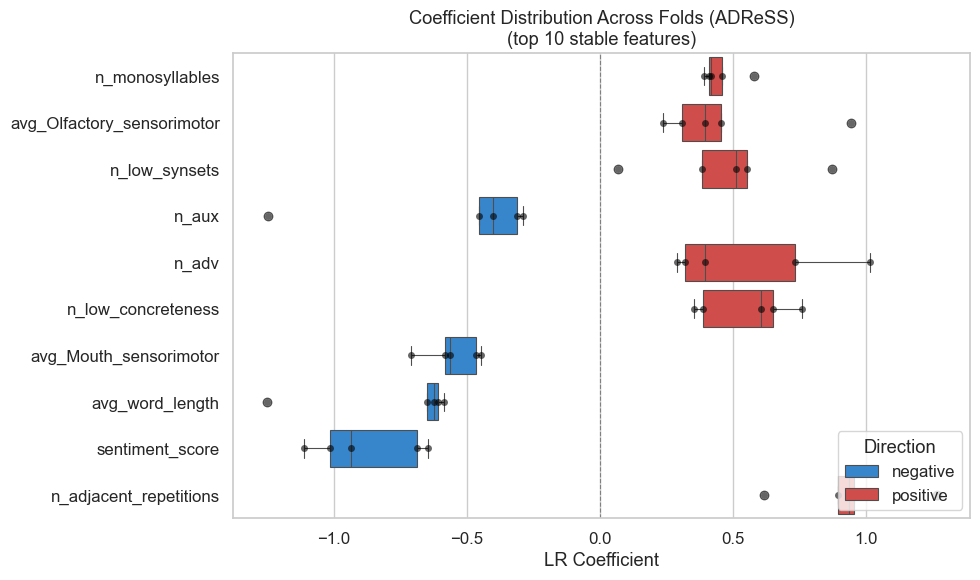

Saved: adress_coefficient_distribution.png


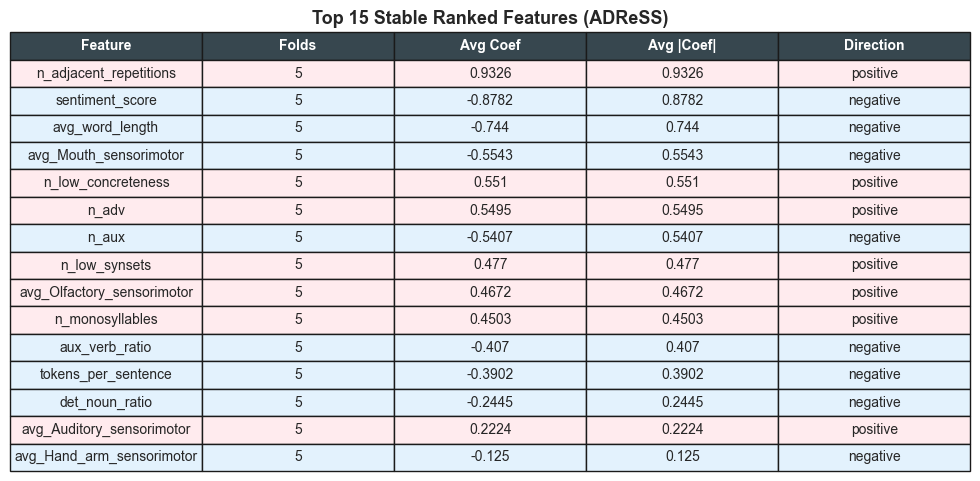

Saved: adress_stable_ranked_table.png


In [9]:
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"positive": "#E53935", "negative": "#1E88E5"}  # red = AD (1), blue = HC (0)

# ── 1. Feature selection frequency across folds ───────────────────────────────
freq = (
    stability_summary[["feature", "selected_folds"]]
    .sort_values("selected_folds", ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[d] for d in stability_summary.set_index("feature").loc[freq["feature"], "majority_direction"]]
ax.bar(freq["feature"], freq["selected_folds"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Feature")
ax.set_ylabel("Folds retained (max 5)")
ax.set_title("Feature Selection Frequency Across Folds (ADReSS)\n(red = AD direction, blue = HC direction)")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "adress_feature_selection_frequency.png"), dpi=150)
plt.show()
print("Saved: adress_feature_selection_frequency.png")

# ── 2. Stable features ranked by avg absolute coefficient ─────────────────────
top = stable_ranked_features.head(15).iloc[::-1]  # reverse for horizontal bar
fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [PALETTE[d] for d in top["majority_direction"]]
ax.barh(top["feature"], top["avg_abs_coefficient"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Avg |Coefficient|")
ax.set_title("Top 15 Stable Features – Avg Absolute LR Coefficient (ADReSS)\n(red = AD direction, blue = HC direction)")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "adress_stable_features_coefficients.png"), dpi=150)
plt.show()
print("Saved: adress_stable_features_coefficients.png")

# ── 3. Coefficient distribution across folds (top 10 stable features) ─────────
top10 = stable_ranked_features["feature"].head(10).tolist()
plot_df = fold_coef_df[fold_coef_df["feature"].isin(top10)].copy()
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=top10[::-1], ordered=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_df, y="feature", x="coefficient",
    palette={"positive": "#E53935", "negative": "#1E88E5"},
    hue="direction", dodge=False, ax=ax, linewidth=0.8,
)
sns.stripplot(
    data=plot_df, y="feature", x="coefficient",
    color="black", size=5, alpha=0.6, jitter=False, ax=ax,
)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("LR Coefficient")
ax.set_ylabel("")
ax.set_title("Coefficient Distribution Across Folds (ADReSS)\n(top 10 stable features)")
ax.legend(title="Direction", loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "adress_coefficient_distribution.png"), dpi=150)
plt.show()
print("Saved: adress_coefficient_distribution.png")

# ── 4. Top-15 stable features as a table image ────────────────────────────────
table_data = stable_ranked_features[
    ["feature", "selected_folds", "avg_coefficient", "avg_abs_coefficient", "majority_direction"]
].head(15).copy()
table_data["avg_coefficient"] = table_data["avg_coefficient"].round(4)
table_data["avg_abs_coefficient"] = table_data["avg_abs_coefficient"].round(4)
table_data.columns = ["Feature", "Folds", "Avg Coef", "Avg |Coef|", "Direction"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
directions = table_data["Direction"].tolist()
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#37474F")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        direction = directions[row - 1]
        if direction == "positive":
            cell.set_facecolor("#FFEBEE")  # light red — AD
        else:
            cell.set_facecolor("#E3F2FD")  # light blue — HC
ax.set_title("Top 15 Stable Ranked Features (ADReSS)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "adress_stable_ranked_table.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: adress_stable_ranked_table.png")

## In-Domain Confusion Matrix (ADReSS)

Aggregated predictions are collected by re-running the identical L1 CV pipeline with the same hyperparameters and random seed. The confusion matrix is **row-normalized** (each row sums to 100 %).

> **Leakage prevention**: `StandardScaler` is fit on the training fold only and applied to the held-out fold — identical to the main CV above.

In [10]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix as _sk_cm

# Re-create the same splitter used in the main CV loop
if USE_GROUPS:
    _splitter  = StratifiedGroupKFold(n_splits=5)
    _split_iter = _splitter.split(X_pruned, y, groups)
else:
    _splitter  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    _split_iter = _splitter.split(X_pruned, y)

_all_true, _all_pred = [], []

for _train_idx, _test_idx in _split_iter:
    _X_tr, _X_te = X_pruned.iloc[_train_idx], X_pruned.iloc[_test_idx]
    _y_tr, _y_te = y[_train_idx], y[_test_idx]

    # LEAKAGE PREVENTION: scaler fit on training fold only
    _sc = StandardScaler()
    _X_tr_s = pd.DataFrame(_sc.fit_transform(_X_tr), columns=retained).fillna(0)
    _X_te_s = pd.DataFrame(_sc.transform(_X_te),     columns=retained).fillna(0)

    # Same L1 LR as main loop
    _lr = LogisticRegression(penalty='l1', solver='liblinear',
                              class_weight='balanced', max_iter=5000, C=1.0)
    _lr.fit(_X_tr_s, _y_tr)
    _all_true.extend(_y_te.tolist())
    _all_pred.extend(_lr.predict(_X_te_s).tolist())

_all_true = np.array(_all_true)
_all_pred = np.array(_all_pred)

# Confusion matrix: labels=[0,1] → HC=row0, AD=row1
adress_cm_raw  = _sk_cm(_all_true, _all_pred, labels=[0, 1])
adress_cm_norm = (adress_cm_raw.astype(float)
                  / adress_cm_raw.sum(axis=1, keepdims=True))
print('Raw:\n', adress_cm_raw)
print('Normalized:\n', adress_cm_norm.round(3))


Raw:
 [[64 14]
 [24 54]]
Normalized:
 [[0.821 0.179]
 [0.308 0.692]]


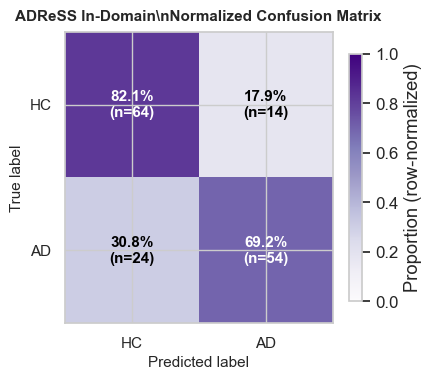

Saved: /Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations/adress_in_domain_confusion_matrix.png
Saved: adress_in_domain_confusion_matrix.csv


In [ ]:
_title  = 'ADReSS In-Domain\\nNormalized Confusion Matrix'
_saveto = os.path.join(VIZ_DIR, 'adress_in_domain_confusion_matrix.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(adress_cm_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = adress_cm_norm[_i, _j] * 100
        _count = adress_cm_raw[_i, _j]
        _col   = 'white' if adress_cm_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

# Save CSV
_rows = []
for _ti, _tl in enumerate(['HC', 'AD']):
    for _pi, _pl in enumerate(['HC', 'AD']):
        _rows.append({'dataset': 'ADReSS', 'true_label': _tl,
                      'predicted_label': _pl,
                      'normalized_value': round(float(adress_cm_norm[_ti, _pi]), 4),
                      'raw_count': int(adress_cm_raw[_ti, _pi])})
pd.DataFrame(_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'adress_in_domain_confusion_matrix.csv'), index=False)
print('Saved: adress_in_domain_confusion_matrix.csv')
